In [1]:
import tgp
from tgp.plot import paper
import xarray as xr

In [2]:
ds_T0 = xr.load_dataset('../data/PRL130_207001.nc')
ds_T0 = tgp.prepare.prepare(ds_T0)

In [3]:
ds_T0

<xarray.Dataset>
Dimensions:            (cutter_pair_index: 5, B: 101, V: 61, bias: 101)
Coordinates:
  * bias               (bias) float64 -0.125 -0.1225 -0.12 ... 0.12 0.1225 0.125
  * B                  (B) float64 0.0 0.0175 0.035 0.0525 ... 1.715 1.732 1.75
  * V                  (V) float64 0.0 0.1 0.2 0.3 0.4 ... 5.6 5.7 5.8 5.9 6.0
  * cutter_pair_index  (cutter_pair_index) int64 0 1 2 3 4
Data variables:
    g_ll               (cutter_pair_index, B, V, bias) float64 0.004004 ... 0...
    g_lr               (cutter_pair_index, B, V, bias) float64 3.584e-47 ... ...
    g_rl               (cutter_pair_index, B, V, bias) float64 2.871e-47 ... ...
    g_rr               (cutter_pair_index, B, V, bias) float64 0.002564 ... 0...
    L_SI               (cutter_pair_index, B, V) float64 1.0 1.0 ... 0.9984
    R_SI               (cutter_pair_index, B, V) float64 1.0 1.0 ... 0.9984
    μ_L                (cutter_pair_index) float64 -0.1 -0.05 0.0 0.05 0.1
    μ_R                (cutter_pair_index) float64 -0.1 -0.05 0.0 0.05 0.1
Attributes: (12/27)
    t_L:                       100
    t_R:                       100
    μ_leadL:                   40
    μ_leadR:                   40
    N_L:                       90
    N_R:                       94
    ...                        ...
    metadata.version.numpy:    1.25.2
    metadata.version.sklearn:  1.2.2
    metadata.version.xarray:   2023.8.0
    metadata.user:             runner
    metadata.date:             2023-08-21 02:14:51
    metadata.platform:         Linux-5.15.0-1042-azure-x86_64-with-glibc2.35

In [4]:
# Perform temperature broadening
ds = tgp.prepare.broaden_with_temperature(ds_T0, T_mK=40)

In [5]:
# Inspect data
ds_left = ds.rename({"bias": "left_bias"})
ds_right = ds.rename({"bias": "right_bias"})
tgp.plot.two.plot_data_interactive(ds_left, ds_right)

interactive(children=(SelectionSlider(continuous_update=False, description='V', layout=Layout(width='500px'), …

In [6]:
# Identify regions of zero bias peaks and finite gap
ds_left, ds_right = tgp.two.extract_gap(ds_left, ds_right)
zbp_ds = tgp.two.zbp_dataset_derivative(ds_left, ds_right, average_over_cutter=False)
tgp.two.set_gap_threshold(zbp_ds, threshold_high=None)
zbp_ds = tgp.two.cluster_and_score(zbp_ds)

Text(0.5, 0, '$B$ [meV]')

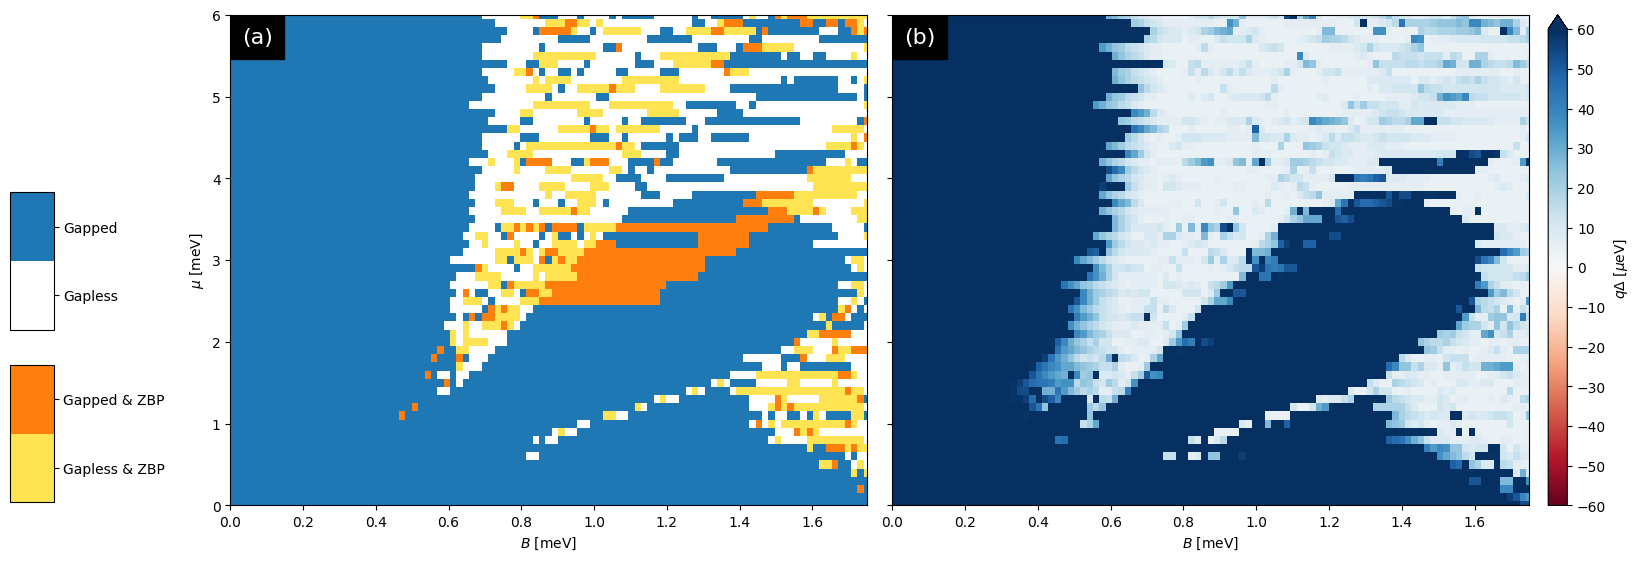

In [7]:
selected_cutter = int(ds.where(ds["μ_L"] == 0.0, drop =True).cutter_pair_index)
fig, axs = tgp.plot.paper.plot_stage2_diagram(zbp_ds, cutter_value=selected_cutter, zbp_cluster_numbers="all")
axs[0].set_ylabel(r'$\mu$ [meV]')
axs[0].set_xlabel(r'$B$ [meV]')
axs[1].set_xlabel(r'$B$ [meV]')